# 결정 트리는 어떤 변수로, 어떻게 가지를 치는가

## 학습 목표

- **불순도**(impurity)를 **지니 지수**(Gini index)와 **엔트로피**(entropy) 두 가지로 계산할 수 있다.
- 한 번의 분할이 얼마나 좋은지 **정보 이득**(information gain)으로 측정할 수 있다.
- 결정 트리가 "모든 변수와 모든 분할점 중에서 정보 이득이 가장 큰 것"을 고른다는 **변수 선택 원리**를 설명할 수 있다.
- 학습된 트리를 그림으로 그리고, 각 노드의 불순도와 **변수 중요도**(feature importance)를 해석할 수 있다.

---

## 사용 데이터

**사이킷런 와인 데이터**를 다시 사용한다. 이번에는 와인 178개를 화학 성분 13종으로 보고 **세 품종**(class 0, 1, 2) 중 어느 것인지 맞히는 **분류**(classification) 문제다. 결정 트리가 13개 변수 중 무엇을 먼저 보고 가지를 치는지 추적하는 것이 이 노트북의 핵심이다.


## 1. 결정 트리는 스무고개다

결정 트리는 "예/아니오"로 답하는 질문을 반복해 답을 좁혀 가는 **스무고개**와 같다. 와인 품종을 맞힌다고 하자.

- "색의 진하기(color_intensity)가 3.8보다 큰가?" → 아니오
- "프롤린(proline)이 755보다 큰가?" → 예
- → 이 와인은 품종 0이다.

이때 트리가 풀어야 할 문제는 단 하나다. **어떤 변수를, 어떤 값에서 잘라야 가장 효율적으로 품종이 갈리는가.** 좋은 질문 하나는 뒤섞여 있던 와인들을 한쪽은 거의 품종 0, 다른 쪽은 거의 품종 1·2로 깔끔하게 나눈다. 이 "깔끔함"을 수치로 재는 도구가 불순도다.

## 2. 불순도: 한 무더기가 얼마나 뒤섞여 있는가

한 노드에 와인들이 모여 있을 때, 이들이 한 품종으로만 이루어져 있으면 **순수**(pure)하고, 여러 품종이 골고루 섞여 있으면 **불순**(impure)하다. 불순도를 재는 두 가지 대표 척도가 있다.

각 클래스 $k$의 비율을 $p_k$라 하자.

**지니 지수**(Gini index)

$$G = 1 - \sum_{k} p_k^{2}$$

무더기에서 와인 두 개를 무작위로 뽑았을 때 둘의 품종이 서로 다를 확률이다. 한 품종뿐이면 0, 골고루 섞일수록 커진다.

**엔트로피**(entropy)

$$H = -\sum_{k} p_k \log_2 p_k$$

무더기의 "혼란도"이며, 정보 이론에서 불확실성을 비트(bit) 단위로 잰 값이다. 한 품종뿐이면 0, 골고루 섞일수록 커진다.

둘 다 "순수하면 0, 섞이면 큰 값"이라는 성질은 같다. 먼저 함수로 직접 구현해 본다.

In [1]:
# 한글 폰트
try:
    import koreanize_matplotlib
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "koreanize-matplotlib"])
    import koreanize_matplotlib

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['figure.dpi'] = 110

NAVY, CRIMSON, GREEN, GRAY = '#1F3A5F', '#C0392B', '#5A8C5A', '#7B8794'

def gini(counts):
    # 클래스별 개수 리스트를 받아 지니 지수를 돌려준다
    counts = np.array(counts, dtype=float)
    n = counts.sum()
    if n == 0:
        return 0.0
    p = counts / n
    return 1.0 - np.sum(p ** 2)

def entropy(counts):
    # 클래스별 개수 리스트를 받아 엔트로피를 돌려준다
    counts = np.array(counts, dtype=float)
    n = counts.sum()
    if n == 0:
        return 0.0
    p = counts / n
    p = p[p > 0]                       # log(0) 방지
    return -np.sum(p * np.log2(p))

# 예시: 한 무더기가 [순수], [반반], [골고루]일 때
print("순수  [10, 0, 0]  → 지니", round(gini([10,0,0]),3), "| 엔트로피", round(entropy([10,0,0]),3))
print("반반  [5, 5, 0]   → 지니", round(gini([5,5,0]),3),  "| 엔트로피", round(entropy([5,5,0]),3))
print("골고루[4, 3, 3]   → 지니", round(gini([4,3,3]),3),  "| 엔트로피", round(entropy([4,3,3]),3))

순수  [10, 0, 0]  → 지니 0.0 | 엔트로피 -0.0
반반  [5, 5, 0]   → 지니 0.5 | 엔트로피 1.0
골고루[4, 3, 3]   → 지니 0.66 | 엔트로피 1.571


두 클래스만 있는 가장 단순한 경우, 한쪽 클래스 비율 $p$를 0에서 1까지 움직이며 불순도가 어떻게 변하는지 그려 본다. $p=0.5$(반반)에서 가장 불순하고, $p=0$ 또는 $p=1$(한 품종뿐)에서 0이 되는 봉우리 모양이 핵심이다.

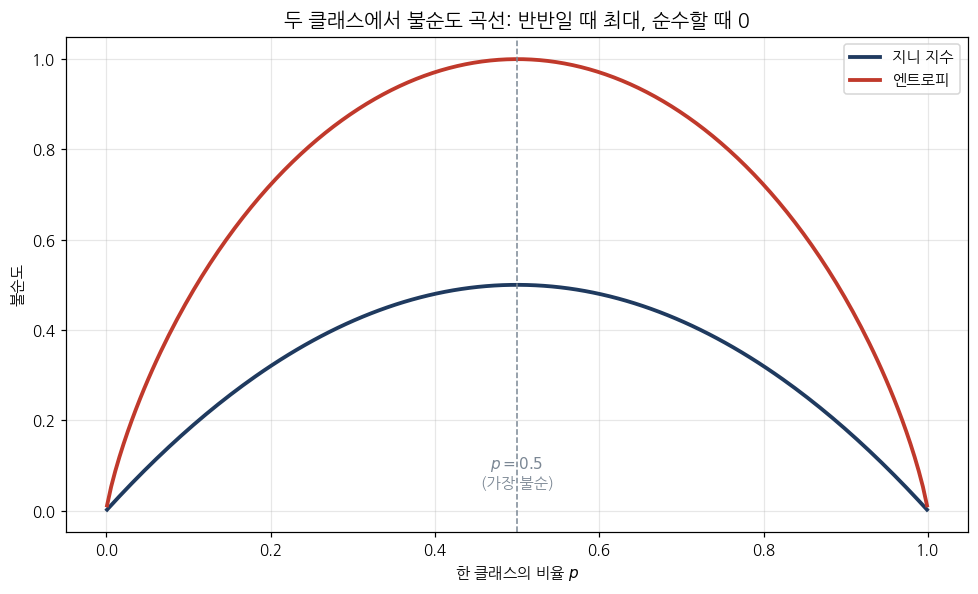

In [2]:
p = np.linspace(0.001, 0.999, 200)
gini_curve = 1 - (p**2 + (1-p)**2)
entropy_curve = -(p*np.log2(p) + (1-p)*np.log2(1-p))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(p, gini_curve, color=NAVY, linewidth=2.5, label='지니 지수')
ax.plot(p, entropy_curve, color=CRIMSON, linewidth=2.5, label='엔트로피')
ax.axvline(0.5, color=GRAY, linestyle='--', linewidth=1)
ax.text(0.5, 0.05, '$p=0.5$\n(가장 불순)', ha='center', color=GRAY, fontsize=10)
ax.set_xlabel('한 클래스의 비율 $p$')
ax.set_ylabel('불순도')
ax.set_title('두 클래스에서 불순도 곡선: 반반일 때 최대, 순수할 때 0', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 개념 확인

엔트로피 곡선이 지니보다 봉우리가 더 높다(최댓값 1 대 0.5). 두 척도 모두 "반반에서 최대, 순수에서 0"이라는 모양은 같으므로, 어느 것을 써도 트리가 고르는 분할은 대체로 비슷하다. 사이킷런의 기본값은 지니이며, 엔트로피는 `criterion='entropy'`로 지정한다.

## 3. 와인 데이터의 출발점 불순도

와인 데이터를 불러오고, 아무 질문도 하지 않은 **루트 노드**(root node)의 불순도를 잰다. 세 품종이 59, 71, 48개로 섞여 있으므로 불순도가 높을 것이다.

In [3]:
try:
    from sklearn.datasets import load_wine
    wine = load_wine()
    X, y = wine.data, wine.target
    feature_names = list(wine.feature_names)
    class_names = [f"품종{i}" for i in range(len(wine.target_names))]
except Exception:
    rng = np.random.default_rng(42)
    X = rng.normal(0, 1, (178, 13)); y = rng.integers(0, 3, 178)
    feature_names = [f"x{i}" for i in range(13)]; class_names = ['품종0','품종1','품종2']

counts = np.bincount(y)
print("세 품종 개수:", counts.tolist())
print("루트 지니   :", round(gini(counts), 4))
print("루트 엔트로피:", round(entropy(counts), 4))

세 품종 개수: [59, 71, 48]
루트 지니   : 0.6583
루트 엔트로피: 1.5668


## 4. 정보 이득: 분할이 불순도를 얼마나 줄였는가

질문 하나로 무더기를 둘로 가르면, 두 자식 노드가 생긴다. 좋은 질문은 자식들을 부모보다 훨씬 순수하게 만든다. 이 "줄어든 불순도"가 **정보 이득**이다.

$$\text{정보 이득} = H(\text{부모}) - \left( \frac{n_{\text{왼쪽}}}{n} H(\text{왼쪽}) + \frac{n_{\text{오른쪽}}}{n} H(\text{오른쪽}) \right)$$

자식 불순도는 그냥 더하지 않고, 각 자식에 들어간 샘플 수의 비율로 **가중 평균**한다. 샘플이 많은 쪽의 불순도가 더 중요하기 때문이다. 정보 이득이 클수록 좋은 질문이다.

프롤린(proline)을 755에서 자르는 질문 하나의 정보 이득을 손으로 계산해 본다.

In [4]:
j = feature_names.index('proline')
threshold = 755.0

mask = X[:, j] <= threshold
left_y, right_y = y[mask], y[~mask]
n = len(y)

H_parent = entropy(np.bincount(y, minlength=3))
H_left   = entropy(np.bincount(left_y,  minlength=3))
H_right  = entropy(np.bincount(right_y, minlength=3))
H_children = len(left_y)/n * H_left + len(right_y)/n * H_right
info_gain = H_parent - H_children

print(f"부모 엔트로피        : {H_parent:.4f}")
print(f"왼쪽(proline<=755) {len(left_y):3d}개 엔트로피: {H_left:.4f}  구성 {np.bincount(left_y,minlength=3).tolist()}")
print(f"오른쪽(proline>755) {len(right_y):3d}개 엔트로피: {H_right:.4f}  구성 {np.bincount(right_y,minlength=3).tolist()}")
print(f"자식 가중평균 엔트로피: {H_children:.4f}")
print(f"정보 이득            : {info_gain:.4f}")

부모 엔트로피        : 1.5668
왼쪽(proline<=755) 111개 엔트로피: 1.0745  구성 [2, 67, 42]
오른쪽(proline>755)  67개 엔트로피: 0.7529  구성 [57, 4, 6]
자식 가중평균 엔트로피: 0.9535
정보 이득            : 0.6133


계산 결과를 그림으로 보면, 부모의 뒤섞인 무더기가 한쪽은 품종 0이 몰리고 다른 쪽은 품종 1·2가 몰리는 식으로 갈라진다. 분할 전후의 불순도 감소를 한 장으로 나타낸다.

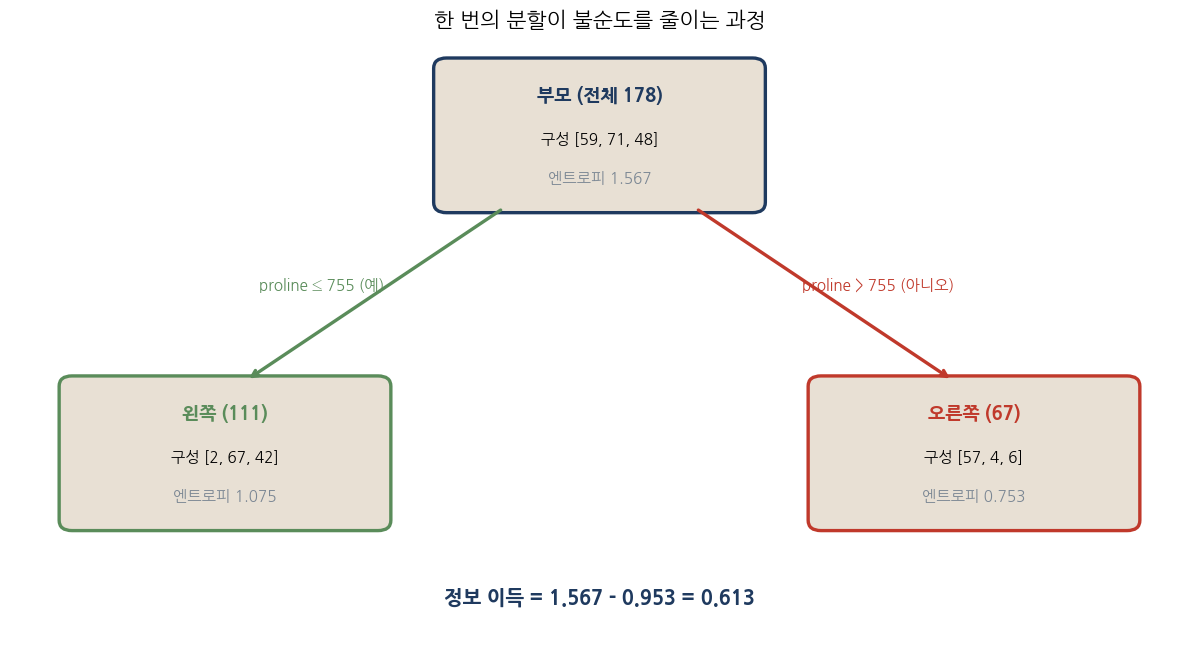

In [5]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 11); ax.set_ylim(0, 7); ax.axis('off')

def node_box(x, y, counts, title, h_val, color):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), 3.0, 1.7, boxstyle="round,pad=0.05,rounding_size=0.12",
        facecolor='#E8E0D4', edgecolor=color, linewidth=2.2))
    ax.text(x+1.5, y+1.25, title, ha='center', fontsize=12, fontweight='bold', color=color)
    ax.text(x+1.5, y+0.75, f"구성 {np.asarray(counts).tolist()}", ha='center', fontsize=10)
    ax.text(x+1.5, y+0.30, f"엔트로피 {h_val:.3f}", ha='center', fontsize=10, color=GRAY)

node_box(4.0, 5.0, np.bincount(y, minlength=3), '부모 (전체 178)', H_parent, NAVY)
node_box(0.5, 1.3, np.bincount(left_y, minlength=3), f'왼쪽 ({len(left_y)})', H_left, GREEN)
node_box(7.5, 1.3, np.bincount(right_y, minlength=3), f'오른쪽 ({len(right_y)})', H_right, CRIMSON)

ax.annotate('', xy=(2.2, 3.0), xytext=(4.6, 5.0),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=2.2))
ax.text(2.9, 4.05, 'proline ≤ 755 (예)', ha='center', fontsize=10, color=GREEN)
ax.annotate('', xy=(8.8, 3.0), xytext=(6.4, 5.0),
            arrowprops=dict(arrowstyle='->', color=CRIMSON, lw=2.2))
ax.text(8.1, 4.05, 'proline > 755 (아니오)', ha='center', fontsize=10, color=CRIMSON)
ax.text(5.5, 0.4, f'정보 이득 = {H_parent:.3f} - {H_children:.3f} = {info_gain:.3f}',
        ha='center', fontsize=13, fontweight='bold', color=NAVY)
ax.set_title('한 번의 분할이 불순도를 줄이는 과정', fontsize=14)
plt.tight_layout()
plt.show()

## 5. 변수 선택: 모든 변수의 최고 분할을 겨루게 한다

결정 트리는 변수 하나를 미리 정해 두지 않는다. **13개 변수 각각에 대해 가능한 모든 분할점을 시험하고, 그중 정보 이득이 가장 큰 (변수, 분할점) 한 쌍**을 골라 루트의 질문으로 삼는다. 이것이 트리의 변수 선택 원리다.

각 변수의 "최선의 분할"이 주는 정보 이득을 직접 구해 막대그래프로 비교하면, 트리가 왜 특정 변수를 먼저 고르는지 한눈에 보인다.

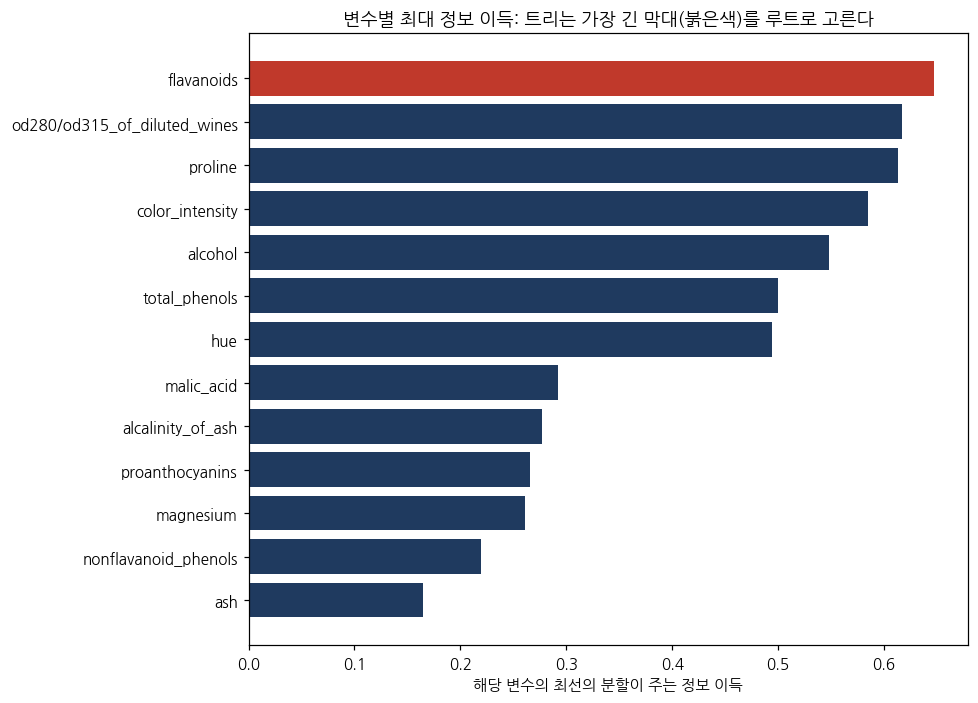

정보 이득 1위 변수: flavanoids → 트리가 첫 질문으로 선택


In [6]:
def best_gain_for_feature(j):
    # 변수 j의 모든 분할점 중 최대 정보 이득을 돌려준다
    values = np.unique(X[:, j])
    thresholds = (values[:-1] + values[1:]) / 2     # 인접 값의 중점들
    H_parent = entropy(np.bincount(y, minlength=3))
    best = 0.0
    for t in thresholds:
        m = X[:, j] <= t
        l, r = y[m], y[~m]
        Hc = len(l)/n*entropy(np.bincount(l,minlength=3)) + len(r)/n*entropy(np.bincount(r,minlength=3))
        best = max(best, H_parent - Hc)
    return best

gains = np.array([best_gain_for_feature(j) for j in range(len(feature_names))])
order = np.argsort(gains)

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh([feature_names[i] for i in order], gains[order], color=NAVY)
ax.barh(feature_names[order[-1]], gains[order[-1]], color=CRIMSON)   # 1등 강조
ax.set_xlabel('해당 변수의 최선의 분할이 주는 정보 이득')
ax.set_title('변수별 최대 정보 이득: 트리는 가장 긴 막대(붉은색)를 루트로 고른다', fontsize=12)
plt.tight_layout()
plt.show()

print("정보 이득 1위 변수:", feature_names[order[-1]], "→ 트리가 첫 질문으로 선택")

## 6. 실제 트리를 학습하고 그림으로 본다

이제 사이킷런에 맡겨 트리를 학습한다. `criterion='entropy'`로 엔트로피 기준을 쓰고, 그림이 한눈에 들어오도록 `max_depth=3`으로 깊이를 제한한다. `plot_tree`가 각 노드의 분할 조건, 엔트로피, 샘플 수, 클래스 구성을 모두 표시한다.

학습 정확도: 0.9944


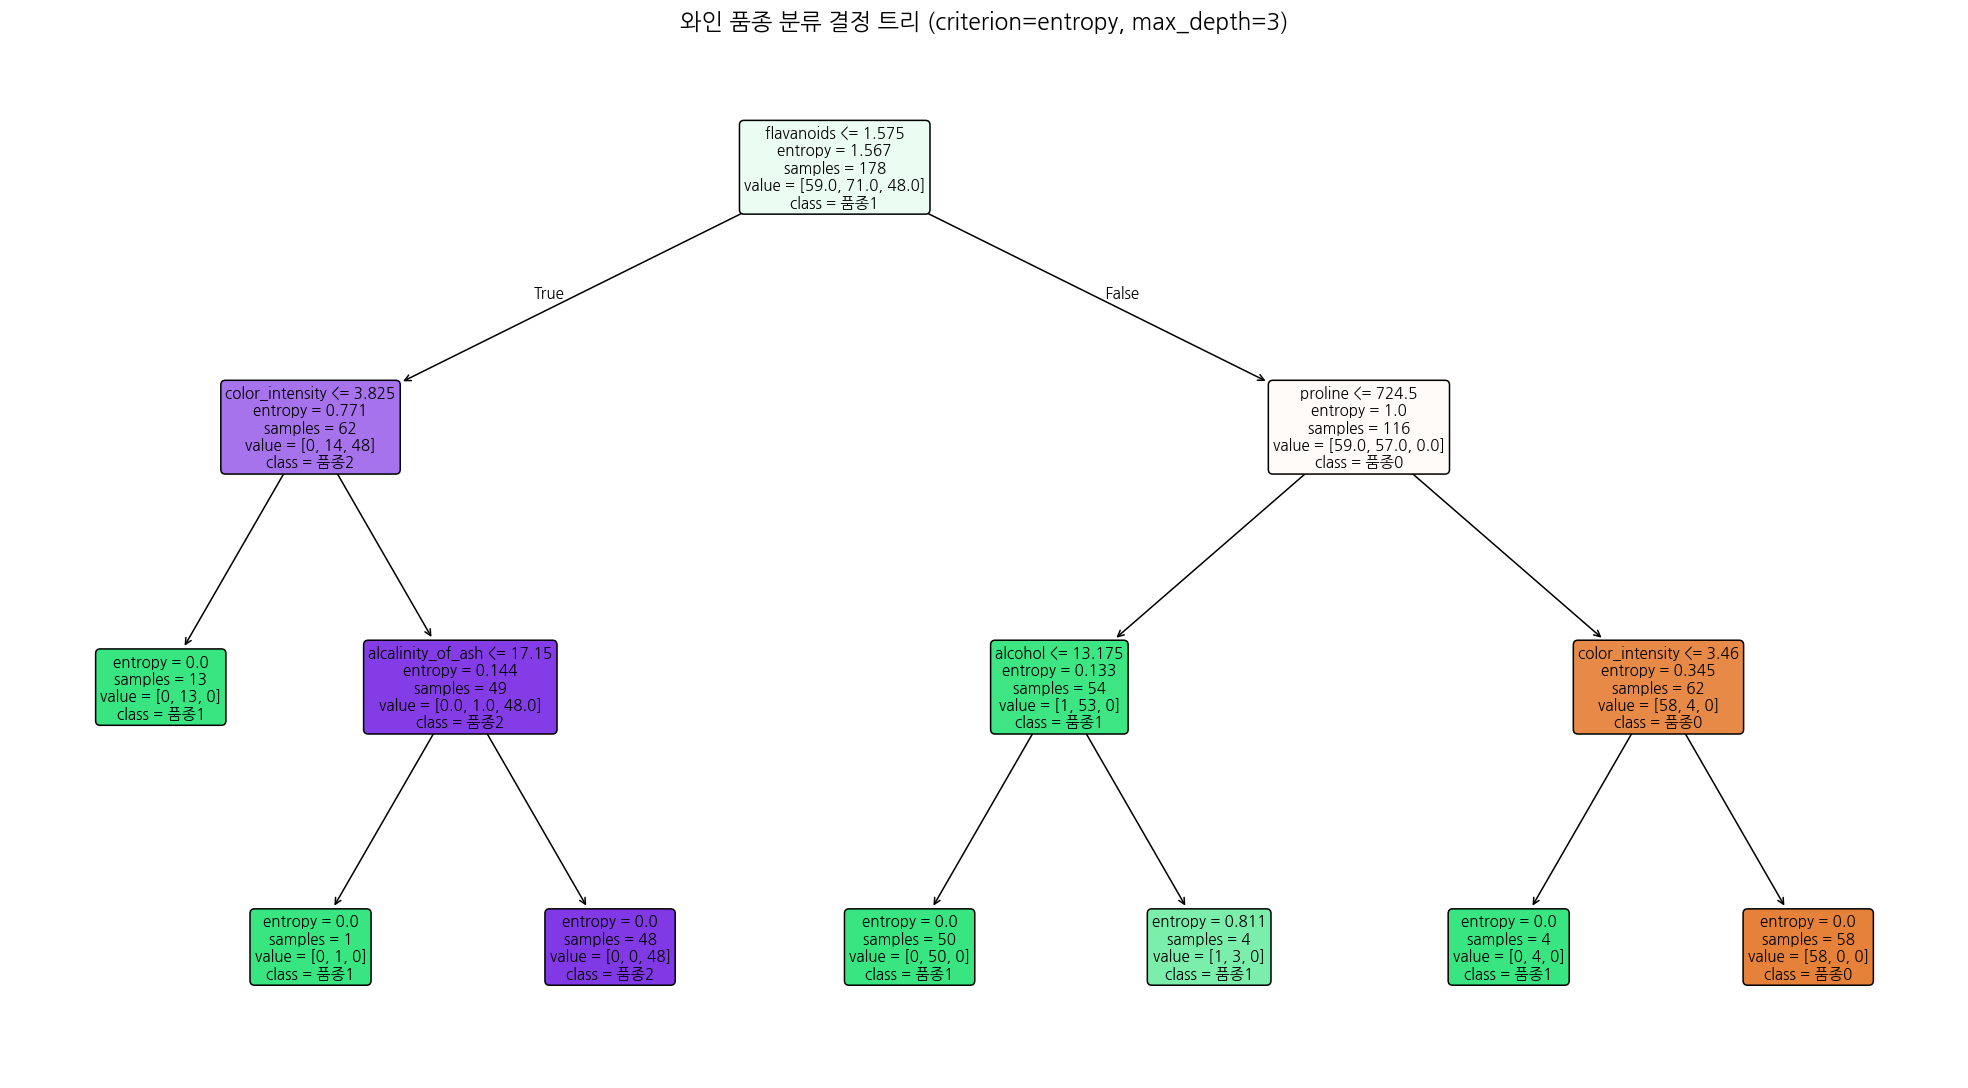

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf.fit(X, y)
print("학습 정확도:", round(clf.score(X, y), 4))

fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(clf, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=10, impurity=True, ax=ax)
ax.set_title('와인 품종 분류 결정 트리 (criterion=entropy, max_depth=3)', fontsize=15)
plt.tight_layout()
plt.show()

### 개념 확인

그림에서 맨 위 루트 노드의 질문이 앞에서 정보 이득 1위로 뽑힌 변수와 일치하는지 확인한다. 각 노드의 `entropy` 값은 아래로 내려갈수록 줄어들고, 한 품종만 남은 **잎 노드**(leaf node)에서는 0에 가까워진다. 색이 진할수록 그 노드가 한 품종으로 순수하게 채워졌다는 뜻이다.

## 7. 변수 중요도: 누가 분류에 가장 크게 기여했는가

트리가 학습되면, 각 변수가 분할에서 줄여 준 불순도를 모두 합산해 **변수 중요도**로 환산한다. 깊이 제한을 풀고 트리를 충분히 키운 뒤 중요도를 본다. 중요도가 0인 변수는 트리가 한 번도 쓰지 않았다는 뜻이며, 이는 라쏘의 변수 선택과 같은 효과다.

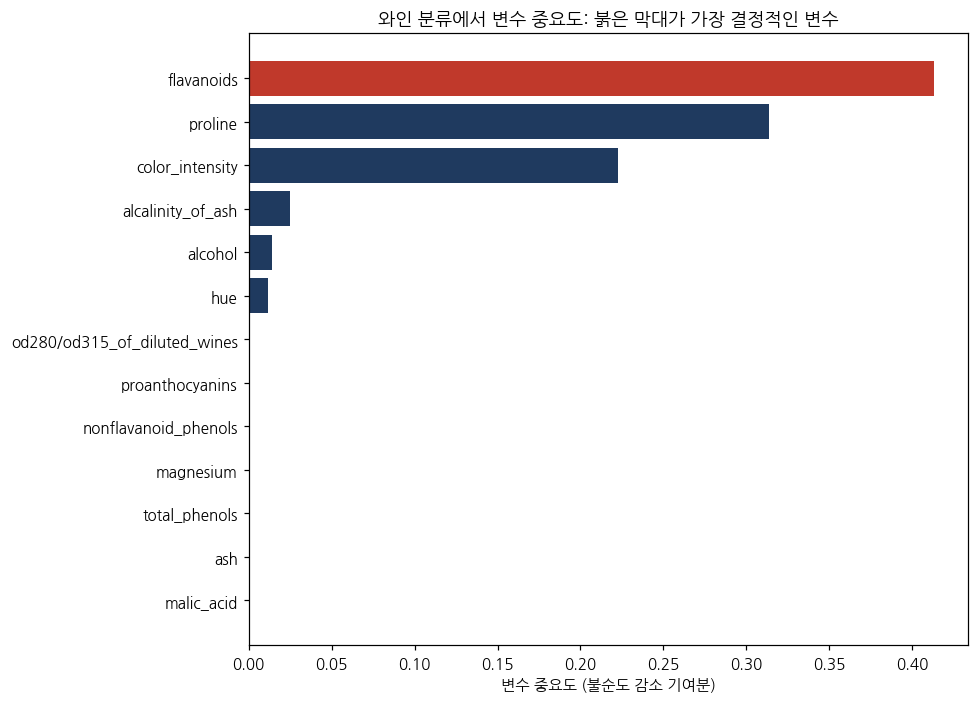

트리가 실제로 사용한 변수: [('flavanoids', np.float64(0.413)), ('proline', np.float64(0.313)), ('color_intensity', np.float64(0.223)), ('alcalinity_of_ash', np.float64(0.025)), ('alcohol', np.float64(0.014)), ('hue', np.float64(0.012))]
한 번도 쓰이지 않은 변수 수: 7


In [8]:
clf_full = DecisionTreeClassifier(criterion='entropy', random_state=42).fit(X, y)
importance = clf_full.feature_importances_
order = np.argsort(importance)

fig, ax = plt.subplots(figsize=(9, 6.5))
colors = [CRIMSON if importance[i] == importance.max() else NAVY for i in order]
ax.barh([feature_names[i] for i in order], importance[order], color=colors)
ax.set_xlabel('변수 중요도 (불순도 감소 기여분)')
ax.set_title('와인 분류에서 변수 중요도: 붉은 막대가 가장 결정적인 변수', fontsize=12)
plt.tight_layout()
plt.show()

used = [(feature_names[i], round(importance[i],3)) for i in order[::-1] if importance[i] > 0]
print("트리가 실제로 사용한 변수:", used)
print("한 번도 쓰이지 않은 변수 수:", int((importance == 0).sum()))

## 8. 깊이가 깊어지면 무슨 일이 생기는가

트리는 깊어질수록 학습 데이터를 더 잘게 나눈다. 이를 눈으로 보기 위해 중요도 상위 두 변수만 골라 평면에 펼치고, `max_depth`를 1부터 키우며 **결정경계**(decision boundary)가 어떻게 변하는지 그린다. 너무 깊으면 경계가 학습 데이터의 잡음까지 따라가는 **과적합**(overfitting)이 나타난다.

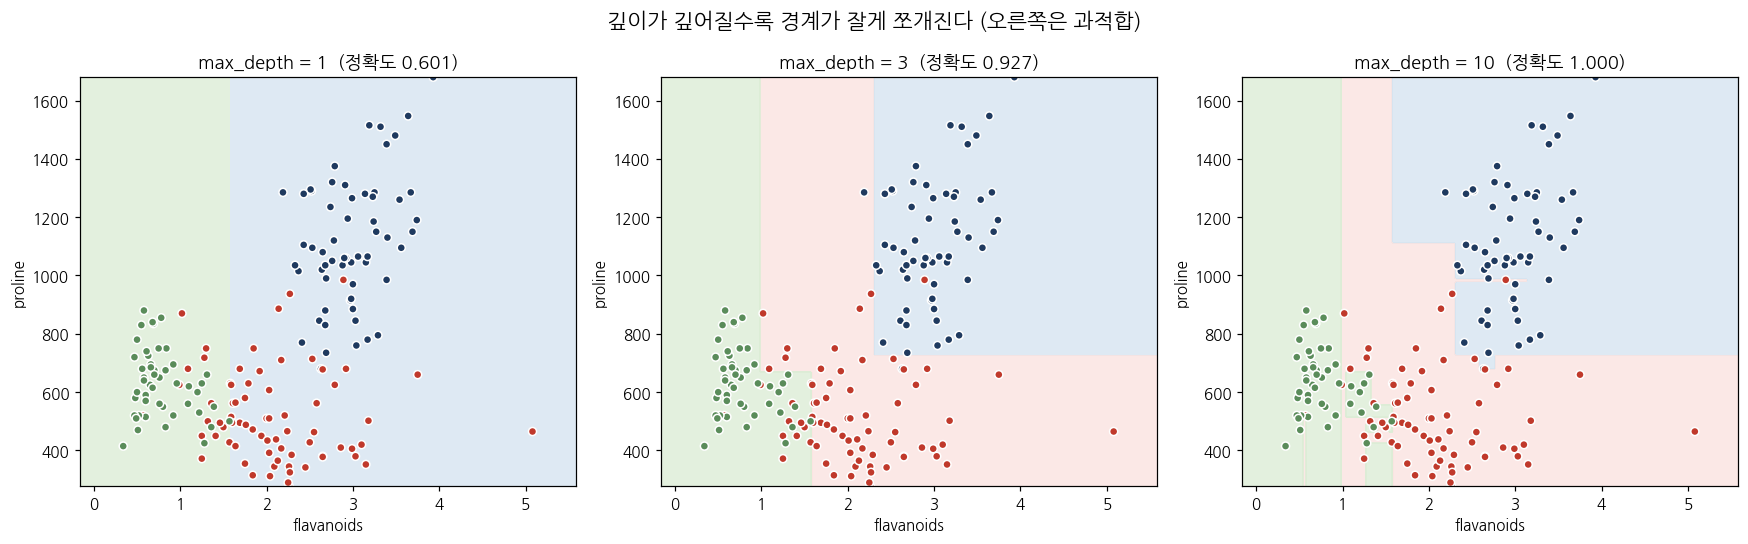

In [9]:
from matplotlib.colors import ListedColormap

top2 = order[::-1][:2]                      # 중요도 상위 두 변수
X2 = X[:, top2]
f1, f2 = feature_names[top2[0]], feature_names[top2[1]]

x_min, x_max = X2[:,0].min()-0.5, X2[:,0].max()+0.5
y_min, y_max = X2[:,1].min()-0.5, X2[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min,x_max,300), np.linspace(y_min,y_max,300))
cmap_bg = ListedColormap(['#D6E4F0', '#FBE3E0', '#DCEDD6'])
cmap_pt = ListedColormap([NAVY, CRIMSON, GREEN])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, depth in zip(axes, [1, 3, 10]):
    t = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42).fit(X2, y)
    Z = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.8)
    ax.scatter(X2[:,0], X2[:,1], c=y, cmap=cmap_pt, edgecolor='white', s=28)
    ax.set_title(f'max_depth = {depth}  (정확도 {t.score(X2,y):.3f})', fontsize=12)
    ax.set_xlabel(f1); ax.set_ylabel(f2)
fig.suptitle('깊이가 깊어질수록 경계가 잘게 쪼개진다 (오른쪽은 과적합)', fontsize=14)
plt.tight_layout()
plt.show()

### 개념 확인

`max_depth=1`은 직선 하나로만 가르므로 너무 단순해 일부를 놓친다. `max_depth=10`은 학습 데이터를 거의 완벽히 맞히지만 경계가 들쭉날쭉해, 새 와인에는 오히려 약하다. 적당한 깊이(가운데)가 균형점이며, 이 균형을 데이터로 찾는 것이 **가지치기**(pruning)와 교차검증의 역할이다.

## 9. 지니와 엔트로피, 결과가 달라지는가

같은 데이터에 기준만 바꿔 두 트리를 학습하고 정확도와 깊이를 비교한다. 대개 두 기준은 거의 같은 트리를 만든다. 엔트로피는 로그 계산이 들어가 약간 느리므로, 실무 기본값은 계산이 가벼운 지니다.

In [10]:
from sklearn.model_selection import cross_val_score

for crit in ['gini', 'entropy']:
    t = DecisionTreeClassifier(criterion=crit, max_depth=3, random_state=42).fit(X, y)
    cv = cross_val_score(t, X, y, cv=5).mean()
    print(f"criterion={crit:8s} | 학습정확도 {t.score(X,y):.4f} | 5겹 CV {cv:.4f} | 깊이 {t.get_depth()}")

criterion=gini     | 학습정확도 0.9775 | 5겹 CV 0.8710 | 깊이 3
criterion=entropy  | 학습정확도 0.9944 | 5겹 CV 0.9103 | 깊이 3


## 10. AI 파이프라인과의 연결

| 결정 트리 개념 | 딥러닝·AI에서의 대응 |
|:---|:---|
| 변수·분할점 선택 | **소프트 결정 트리**(Soft Decision Tree): 분기를 미분 가능한 게이트로 바꿔 신경망과 결합한다. |
| 불순도 감소(엔트로피) | 분류 신경망의 **교차 엔트로피 손실**(cross-entropy loss)과 같은 정보 이론적 뿌리를 공유한다. |
| 변수 중요도 | **SHAP**, **Saliency Map**: 어떤 입력이 예측을 끌어냈는지 설명하는 기법으로 이어진다. |
| 깊이와 과적합 | 신경망의 층 수·드롭아웃과 같은 **모델 복잡도 조절** 문제다. |

엔트로피로 분할을 고르는 결정 트리의 발상은, 분류 신경망이 교차 엔트로피를 줄이며 학습하는 원리와 한 갈래에서 나왔다. 트리에서 익힌 불순도 감소의 직관이 그대로 딥러닝의 손실 함수 이해로 연결된다.

---

## 11. 연습문제

위에서 정의한 `gini`, `entropy`, `X`, `y`, `feature_names`, `n` 변수가 메모리에 있다는 전제로 푼다. 코드 문제는 `____`를 채워 실행하고, 정답은 토글로 확인한다.

### 문제 1. 순수한 노드의 불순도

클래스 구성이 `[20, 0, 0]`인 노드의 지니와 엔트로피를 구하라. 두 값이 모두 무엇이 되는지 확인하라.

In [ ]:
print('지니 :', gini(____))
print('엔트로피:', entropy([20, 0, 0]))

<details><summary>▶ 정답 보기</summary>

```python
print('지니 :', gini([20, 0, 0]))
print('엔트로피:', entropy([20, 0, 0]))
```

한 클래스만 있으면 완전히 순수하므로 지니와 엔트로피 모두 0이다.

</details>

### 문제 2. 가장 불순한 3클래스 노드

세 클래스가 완전히 균등한 `[10, 10, 10]`의 엔트로피를 구하라. 3클래스 최대 엔트로피 $\log_2 3 \approx 1.585$와 비교하라.

In [ ]:
print('엔트로피:', round(entropy([10, 10, 10]), ____))

<details><summary>▶ 정답 보기</summary>

```python
print('엔트로피:', round(entropy([10, 10, 10]), 4))
```

세 클래스가 균등하면 엔트로피는 $\log_2 3 \approx 1.585$로 3클래스에서 가능한 최댓값이다.

</details>

### 문제 3. 정보 이득 직접 계산

`color_intensity` 변수를 3.8에서 자를 때의 정보 이득을 계산하라.

In [ ]:
j = feature_names.index('color_intensity')
mask = X[:, j] <= ____
l, r = y[mask], y[~mask]
Hp = entropy(np.bincount(y, minlength=3))
Hc = len(l)/n*entropy(np.bincount(l,minlength=3)) + len(r)/n*entropy(np.bincount(r,minlength=3))
print('정보 이득:', round(Hp - ____, 4))

<details><summary>▶ 정답 보기</summary>

```python
j = feature_names.index('color_intensity')
mask = X[:, j] <= 3.8
l, r = y[mask], y[~mask]
Hp = entropy(np.bincount(y, minlength=3))
Hc = len(l)/n*entropy(np.bincount(l,minlength=3)) + len(r)/n*entropy(np.bincount(r,minlength=3))
print('정보 이득:', round(Hp - Hc, 4))
```

부모 엔트로피에서 자식들의 가중 평균 엔트로피를 뺀 값이 정보 이득이다.

</details>

### 문제 4. 지니 기준 트리 학습

지니 기준, 깊이 2인 트리를 학습하고 학습 정확도를 출력하라.

In [ ]:
clf2 = DecisionTreeClassifier(criterion='____', max_depth=2, random_state=42).fit(X, y)
print('정확도:', round(clf2.score(X, y), 4))

<details><summary>▶ 정답 보기</summary>

```python
clf2 = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=42).fit(X, y)
print('정확도:', round(clf2.score(X, y), 4))
```

`criterion='gini'`가 지니 기준이며 사이킷런의 기본값이다.

</details>

### 문제 5. 루트 노드의 분할 변수 확인

학습된 `clf_full`에서 루트 노드(인덱스 0)가 어떤 변수로 분할했는지 변수 이름으로 출력하라.

In [ ]:
root_feat_idx = clf_full.tree_.feature[0]
print('루트 분할 변수:', feature_names[____])

<details><summary>▶ 정답 보기</summary>

```python
root_feat_idx = clf_full.tree_.feature[0]
print('루트 분할 변수:', feature_names[root_feat_idx])
```

`tree_.feature[0]`은 루트가 사용한 변수의 인덱스다. 정보 이득 1위 변수와 일치한다.

</details>

### 문제 6. 트리가 쓰지 않은 변수

`clf_full`의 변수 중요도가 정확히 0인 변수 이름을 모두 리스트로 출력하라.

In [ ]:
unused = [f for f, imp in zip(feature_names, clf_full.feature_importances_) if imp == ____]
print('미사용 변수:', unused)

<details><summary>▶ 정답 보기</summary>

```python
unused = [f for f, imp in zip(feature_names, clf_full.feature_importances_) if imp == 0]
print('미사용 변수:', unused)
```

중요도가 0이면 트리가 그 변수를 한 번도 분할에 쓰지 않은 것이다.

</details>

### 문제 7. 깊이와 과적합 (개념)

`max_depth`를 제한하지 않으면 학습 정확도는 보통 1.0에 가까워지는데, 그것이 항상 좋은 모델을 의미하지 않는 이유를 설명하라.

In [ ]:
# 코드 없이 서술형. 아래 정답 확인

<details><summary>▶ 정답 보기</summary>

```python
# 서술형 문제
```

깊이를 제한하지 않으면 트리가 학습 데이터의 잡음까지 외워 학습 정확도는 높아지지만, 경계가 지나치게 복잡해져 새 데이터에 대한 일반화 성능은 오히려 떨어진다. 이것이 과적합이다.

</details>

### 문제 8. 지니 vs 엔트로피 (개념)

실무에서 두 기준 중 지니를 기본값으로 더 자주 쓰는 이유를 한 가지 쓰라.

In [ ]:
# 코드 없이 서술형. 아래 정답 확인

<details><summary>▶ 정답 보기</summary>

```python
# 서술형 문제
```

두 기준이 만드는 트리는 대체로 비슷한데, 엔트로피는 로그 계산이 들어가 약간 더 무겁다. 따라서 계산이 가벼운 지니가 기본값으로 선호된다.

</details>

---

## 마무리

결정 트리는 **불순도**(지니 또는 엔트로피)로 무더기의 뒤섞임을 재고, 모든 변수와 분할점 중 **정보 이득**이 가장 큰 것을 골라 가지를 친다. 이 과정을 반복하면 잎 노드가 점점 순수해지며, 각 변수가 줄여 준 불순도의 총합이 **변수 중요도**가 된다. 깊이를 키울수록 학습 데이터에는 잘 맞지만 과적합 위험이 커지므로, 적절한 깊이를 데이터로 찾는 것이 핵심이다.